# Smartphone Usage Anomaly Detection Project

## Introduction
This notebook presents an anomaly detection study on smartphone usage data for a Big Data Mining course. The goal is not only to detect unusual user behavior, but also to extract interpretable insights from those anomalies.

### Objective
- Detect anomalous smartphone usage patterns using unsupervised learning.
- Compare the behavior of multiple anomaly detection models.
- Combine model outputs using an ensemble rule for more robust final decisions.
- Classify detected anomalies into meaningful behavioral categories.
- Extract report-ready insights from model outputs and visualizations.

### Why Multivariate Anomaly Detection?
Smartphone usage behavior cannot be understood well through only one feature. A user may not look abnormal in terms of screen time alone, but the combination of low sleep, high stress, heavy phone use, and high caffeine intake can reveal risky or unusual behavior. Multivariate anomaly detection is therefore necessary because anomalies often emerge from patterns across several variables rather than from one extreme value.
This submission also includes a reduced processed dataset containing only the variables used in the analysis and the final anomaly-related labels for reporting.


In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
np.random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [2]:
# Load reduced processed dataset for submission if available; otherwise build from the raw CSV.
processed_csv_path = 'smartphone_usage_processed.csv'
raw_csv_path = 'Smartphone_Usage_Productivity_Dataset_50000.csv'

if os.path.exists(processed_csv_path):
    df_processed = pd.read_csv(processed_csv_path)
    df = df_processed[['sleep_hours', 'stress_level', 'screen_time', 'productivity_score', 'caffeine_intake']].copy()
    source_name = 'Processed submission dataset loaded successfully'
elif os.path.exists(raw_csv_path):
    raw_df = pd.read_csv(raw_csv_path)
    df = pd.DataFrame({
        'sleep_hours': raw_df['Sleep_Hours'],
        'stress_level': raw_df['Stress_Level'],
        'screen_time': raw_df['Daily_Phone_Hours'],
        'productivity_score': raw_df['Work_Productivity_Score'] * 10,
        'caffeine_intake': raw_df['Caffeine_Intake_Cups']
    })
    source_name = 'Raw CSV loaded and reduced to the required features'
else:
    n_samples = 500
    sleep_hours = np.clip(np.random.normal(loc=7.0, scale=1.0, size=n_samples), 3.5, 10)
    stress_level = np.clip(np.random.normal(loc=5.0, scale=1.8, size=n_samples), 1, 10)
    screen_time = np.clip(np.random.normal(loc=5.5, scale=1.5, size=n_samples), 1, 12)
    productivity_score = np.clip(np.random.normal(loc=68, scale=12, size=n_samples), 20, 100)
    caffeine_intake = np.clip(np.random.normal(loc=2.0, scale=1.0, size=n_samples), 0, 8)

    df = pd.DataFrame({
        'sleep_hours': sleep_hours,
        'stress_level': stress_level,
        'screen_time': screen_time,
        'productivity_score': productivity_score,
        'caffeine_intake': caffeine_intake
    })

    anomaly_idx = np.random.choice(df.index, size=30, replace=False)
    df.loc[anomaly_idx[:10], ['sleep_hours', 'stress_level', 'screen_time', 'caffeine_intake']] = [3.8, 9.5, 10.5, 6.5]
    df.loc[anomaly_idx[10:20], ['sleep_hours', 'productivity_score', 'screen_time']] = [4.2, 92, 8.5]
    df.loc[anomaly_idx[20:], ['sleep_hours', 'stress_level', 'screen_time', 'productivity_score', 'caffeine_intake']] = [9.5, 2.0, 11.0, 35, 0.2]
    source_name = 'Synthetic dataset generated'

# Add a small amount of missing data for preprocessing demonstration only if the source file is not already processed.
if 'Processed submission dataset loaded successfully' not in source_name:
    df = df.copy()
    for col in df.columns:
        missing_rows = np.random.choice(df.index, size=max(3, int(len(df) * 0.003)), replace=False)
        df.loc[missing_rows, col] = np.nan

print(source_name)
print('Dataset shape:', df.shape)
display(df.head())
display(df.describe())


Processed submission dataset loaded successfully
Dataset shape: (50000, 5)


,sleep_hours,stress_level,screen_time,productivity_score,caffeine_intake
0,8.80,4.00,1.30,60.00,1.00
1,6.40,1.00,1.20,50.00,3.00
2,9.00,4.00,5.30,50.00,5.00
3,5.70,3.00,5.80,20.00,6.00
4,5.70,3.00,7.90,40.00,5.00


,sleep_hours,stress_level,screen_time,productivity_score,caffeine_intake
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,6.50,5.51,6.51,55.05,3.01
std,1.45,2.87,3.17,28.70,1.99
min,4.00,1.00,1.00,10.00,0.00
25%,5.20,3.00,3.80,30.00,1.00
50%,6.50,6.00,6.50,60.00,3.00
75%,7.80,8.00,9.20,80.00,5.00
max,9.00,10.00,12.00,100.00,6.00


## 4. Data Preprocessing

Before applying anomaly detection models, the dataset must be prepared carefully.

### Missing Value Handling
Real-world data often contains missing values. Since the selected scikit-learn models cannot handle missing values directly, the notebook fills missing entries using the median of each feature. Median imputation is appropriate here because it is robust to extreme values and preserves the central tendency of the feature.

### Feature Scaling
The anomaly detection models used in this project are influenced by feature magnitude. For example, `productivity_score` and `stress_level` are measured on different numeric scales. `StandardScaler` transforms all features to a common scale with mean 0 and standard deviation 1, helping each variable contribute more fairly to the models.

In [3]:
# Handle missing values using median imputation.
df_clean = df.copy()
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

print('Missing values after imputation:')
print(df_clean.isna().sum())

# Standardize features.
features = ['sleep_hours', 'stress_level', 'screen_time', 'productivity_score', 'caffeine_intake']
X = df_clean[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\nScaled feature matrix shape:', X_scaled.shape)
display(df_clean.head())

Missing values after imputation:
sleep_hours           0
stress_level          0
screen_time           0
productivity_score    0
caffeine_intake       0
dtype: int64

Scaled feature matrix shape: (50000, 5)


,sleep_hours,stress_level,screen_time,productivity_score,caffeine_intake
0,8.80,4.00,1.30,60.00,1.00
1,6.40,1.00,1.20,50.00,3.00
2,9.00,4.00,5.30,50.00,5.00
3,5.70,3.00,5.80,20.00,6.00
4,5.70,3.00,7.90,40.00,5.00


## 5. Anomaly Detection Models

Three unsupervised anomaly detection algorithms are used in this project. Each model defines abnormality differently, so comparing them helps identify stable anomalies.

### 5.1 Isolation Forest
Isolation Forest works by repeatedly splitting the data space. Anomalies tend to be isolated faster than normal observations, so they receive shorter path lengths and are flagged as abnormal.

### 5.2 Local Outlier Factor
Local Outlier Factor (LOF) identifies points that have much lower local density than their neighbors. It is useful when anomalies appear as sparse local regions rather than global extremes.

### 5.3 One-Class SVM
One-Class SVM learns a boundary around the majority of observations. Samples outside the learned boundary are treated as anomalies.

In [4]:
# 5.1 Isolation Forest
iso_model = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
df_clean['iso_anomaly'] = iso_model.fit_predict(X_scaled)
df_clean['iso_anomaly'] = df_clean['iso_anomaly'].map({1: 0, -1: 1})

print('Isolation Forest anomaly counts:')
print(df_clean['iso_anomaly'].value_counts().sort_index())
display(df_clean[['iso_anomaly']].head())

Isolation Forest anomaly counts:
iso_anomaly
0    47500
1     2500
Name: count, dtype: int64


,iso_anomaly
0,0
1,0
2,0
3,0
4,0


In [5]:
# 5.2 Local Outlier Factor
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_clean['lof_anomaly'] = lof_model.fit_predict(X_scaled)
df_clean['lof_anomaly'] = df_clean['lof_anomaly'].map({1: 0, -1: 1})

print('Local Outlier Factor anomaly counts:')
print(df_clean['lof_anomaly'].value_counts().sort_index())
display(df_clean[['lof_anomaly']].head())

Local Outlier Factor anomaly counts:
lof_anomaly
0    47500
1     2500
Name: count, dtype: int64


,lof_anomaly
0,1
1,1
2,0
3,0
4,0


In [6]:
# 5.3 One-Class SVM
svm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
df_clean['svm_anomaly'] = svm_model.fit_predict(X_scaled)
df_clean['svm_anomaly'] = df_clean['svm_anomaly'].map({1: 0, -1: 1})

print('One-Class SVM anomaly counts:')
print(df_clean['svm_anomaly'].value_counts().sort_index())
display(df_clean[['svm_anomaly']].head())

One-Class SVM anomaly counts:
svm_anomaly
0    47498
1     2502
Name: count, dtype: int64


,svm_anomaly
0,0
1,0
2,0
3,0
4,0


In [7]:
# 6. Ensemble Method: final anomaly if at least 2 out of 3 models agree.
df_clean['anomaly_votes'] = df_clean[['iso_anomaly', 'lof_anomaly', 'svm_anomaly']].sum(axis=1)
df_clean['final_anomaly'] = (df_clean['anomaly_votes'] >= 2).astype(int)

num_anomalies = int(df_clean['final_anomaly'].sum())
pct_anomalies = df_clean['final_anomaly'].mean() * 100

print(f'Number of anomalies: {num_anomalies}')
print(f'Percentage of anomalies: {pct_anomalies:.2f}%')
display(df_clean[['iso_anomaly', 'lof_anomaly', 'svm_anomaly', 'anomaly_votes', 'final_anomaly']].head())

Number of anomalies: 2180
Percentage of anomalies: 4.36%


,iso_anomaly,lof_anomaly,svm_anomaly,anomaly_votes,final_anomaly
0,0,1,0,1,0
1,0,1,0,1,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


Anomaly count per model:
Overlap table between model outputs:
Detailed overlap patterns:


<string>:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


,Model,Anomaly Count
0,Isolation Forest,2500
1,Local Outlier Factor,2500
2,One-Class SVM,2502
3,Ensemble Final,2180


svm_anomaly                  0     1
iso_anomaly lof_anomaly             
0           0            45376   477
            1             1561    86
1           0              406  1241
            1              155   698

,Detection Pattern (ISO-LOF-SVM),Count
0,0-0-0,45376
1,0-1-0,1561
2,1-0-1,1241
3,1-1-1,698
4,0-0-1,477
5,1-0-0,406
6,1-1-0,155
7,0-1-1,86


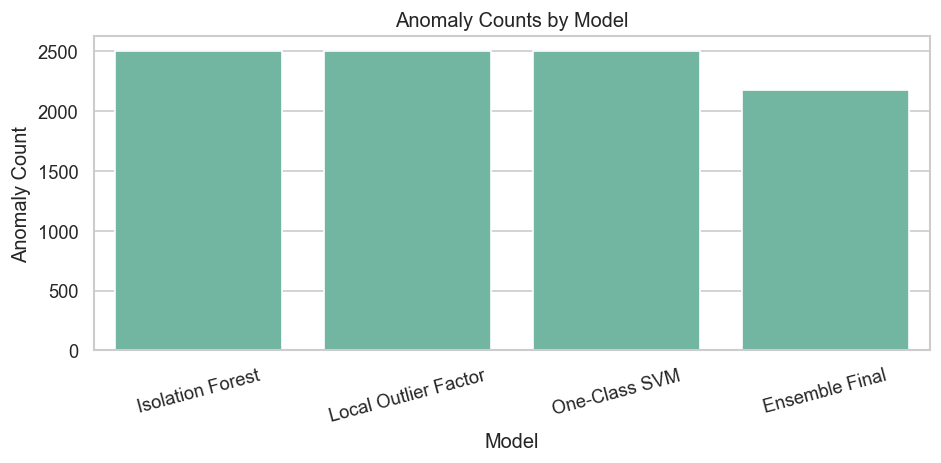

In [8]:
# 7. Model Comparison
model_counts = pd.DataFrame({
    'Model': ['Isolation Forest', 'Local Outlier Factor', 'One-Class SVM', 'Ensemble Final'],
    'Anomaly Count': [
        int(df_clean['iso_anomaly'].sum()),
        int(df_clean['lof_anomaly'].sum()),
        int(df_clean['svm_anomaly'].sum()),
        int(df_clean['final_anomaly'].sum())
    ]
})

print('Anomaly count per model:')
display(model_counts)

overlap_table = pd.crosstab(
    [df_clean['iso_anomaly'], df_clean['lof_anomaly']],
    df_clean['svm_anomaly'],
    rownames=['iso_anomaly', 'lof_anomaly'],
    colnames=['svm_anomaly']
)

print('Overlap table between model outputs:')
display(overlap_table)

agreement_df = df_clean[['iso_anomaly', 'lof_anomaly', 'svm_anomaly']].copy()
agreement_df['pattern'] = agreement_df.astype(str).agg('-'.join, axis=1)
agreement_summary = agreement_df['pattern'].value_counts().reset_index()
agreement_summary.columns = ['Detection Pattern (ISO-LOF-SVM)', 'Count']

print('Detailed overlap patterns:')
display(agreement_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=model_counts, x='Model', y='Anomaly Count')
plt.title('Anomaly Counts by Model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. Taxonomy Classification

A detected anomaly is more useful when it can be described in a meaningful category. In this notebook, anomalies are grouped into three categories:

- **Health-Risk**: users with low sleep and high stress.
- **Productivity Paradox**: users with high productivity despite low sleep.
- **Behavioral Anomaly**: other anomalous patterns that do not fit the first two categories.

Thresholds are defined from the empirical distribution of the dataset to keep the rules adaptive to the data.

In [9]:
# 8. Taxonomy Classification
sleep_threshold = df_clean['sleep_hours'].quantile(0.25)
stress_high_threshold = df_clean['stress_level'].quantile(0.75)
productivity_high_threshold = df_clean['productivity_score'].quantile(0.75)

df_clean['anomaly_type'] = 'Normal'

health_mask = (
    (df_clean['final_anomaly'] == 1) &
    (df_clean['sleep_hours'] < sleep_threshold) &
    (df_clean['stress_level'] >= stress_high_threshold)
)

productivity_mask = (
    (df_clean['final_anomaly'] == 1) &
    (df_clean['productivity_score'] >= productivity_high_threshold) &
    (df_clean['sleep_hours'] < sleep_threshold)
)

df_clean.loc[health_mask, 'anomaly_type'] = 'Health-Risk'
df_clean.loc[productivity_mask & ~health_mask, 'anomaly_type'] = 'Productivity Paradox'
df_clean.loc[(df_clean['final_anomaly'] == 1) & (df_clean['anomaly_type'] == 'Normal'), 'anomaly_type'] = 'Behavioral Anomaly'

anomaly_type_counts = df_clean.loc[df_clean['final_anomaly'] == 1, 'anomaly_type'].value_counts()
anomaly_type_pct = (df_clean.loc[df_clean['final_anomaly'] == 1, 'anomaly_type']
                    .value_counts(normalize=True) * 100)

taxonomy_summary = pd.DataFrame({
    'Count': anomaly_type_counts,
    'Percentage': anomaly_type_pct.round(2)
})

print('Thresholds used for taxonomy classification:')
print(f'Sleep threshold (25th percentile): {sleep_threshold:.2f}')
print(f'Stress threshold (75th percentile): {stress_high_threshold:.2f}')
print(f'Productivity threshold (75th percentile): {productivity_high_threshold:.2f}')

print('\nTaxonomy summary for anomalies:')
display(taxonomy_summary)

print('Preview of anomaly labels:')
display(df_clean[['sleep_hours', 'stress_level', 'productivity_score', 'final_anomaly', 'anomaly_type']].head(10))

Thresholds used for taxonomy classification:
Sleep threshold (25th percentile): 5.20
Stress threshold (75th percentile): 8.00
Productivity threshold (75th percentile): 80.00

Taxonomy summary for anomalies:
Preview of anomaly labels:


,Count,Percentage
anomaly_type,,
Behavioral Anomaly,1507,69.13
Health-Risk,411,18.85
Productivity Paradox,262,12.02


,sleep_hours,stress_level,productivity_score,final_anomaly,anomaly_type
0,8.80,4.00,60.00,0,Normal
1,6.40,1.00,50.00,0,Normal
2,9.00,4.00,50.00,0,Normal
3,5.70,3.00,20.00,0,Normal
4,5.70,3.00,40.00,0,Normal
5,6.30,7.00,90.00,0,Normal
6,6.70,3.00,80.00,0,Normal
7,7.80,3.00,40.00,0,Normal
8,6.40,4.00,30.00,0,Normal
9,4.50,2.00,10.00,0,Normal


Explained variance ratio by PCA components:
[0.20297456 0.20126728]


<string>:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


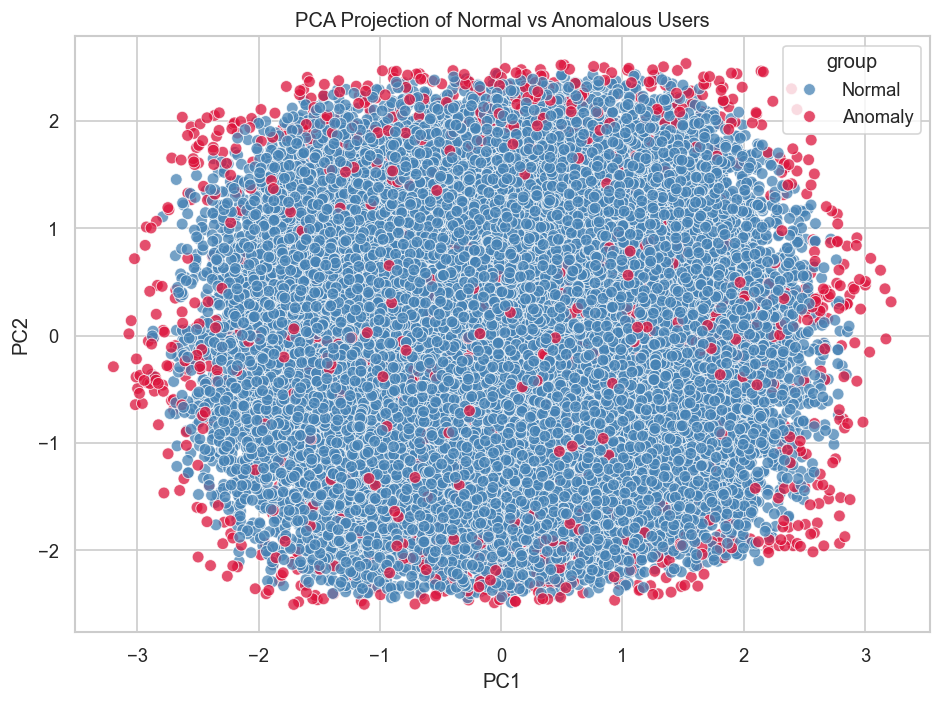

In [10]:
# 9.1 PCA Visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['final_anomaly'] = df_clean['final_anomaly']
pca_df['group'] = pca_df['final_anomaly'].map({0: 'Normal', 1: 'Anomaly'})

print('Explained variance ratio by PCA components:')
print(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='group',
    palette={'Normal': 'steelblue', 'Anomaly': 'crimson'},
    alpha=0.75,
    s=50
)
plt.title('PCA Projection of Normal vs Anomalous Users')
plt.tight_layout()
plt.show()

Average feature values by group:


<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


,sleep_hours,stress_level,screen_time,productivity_score,caffeine_intake
user_group,,,,,
Anomaly,6.41,5.50,6.81,59.05,3.22
Normal,6.50,5.51,6.50,54.87,3.00


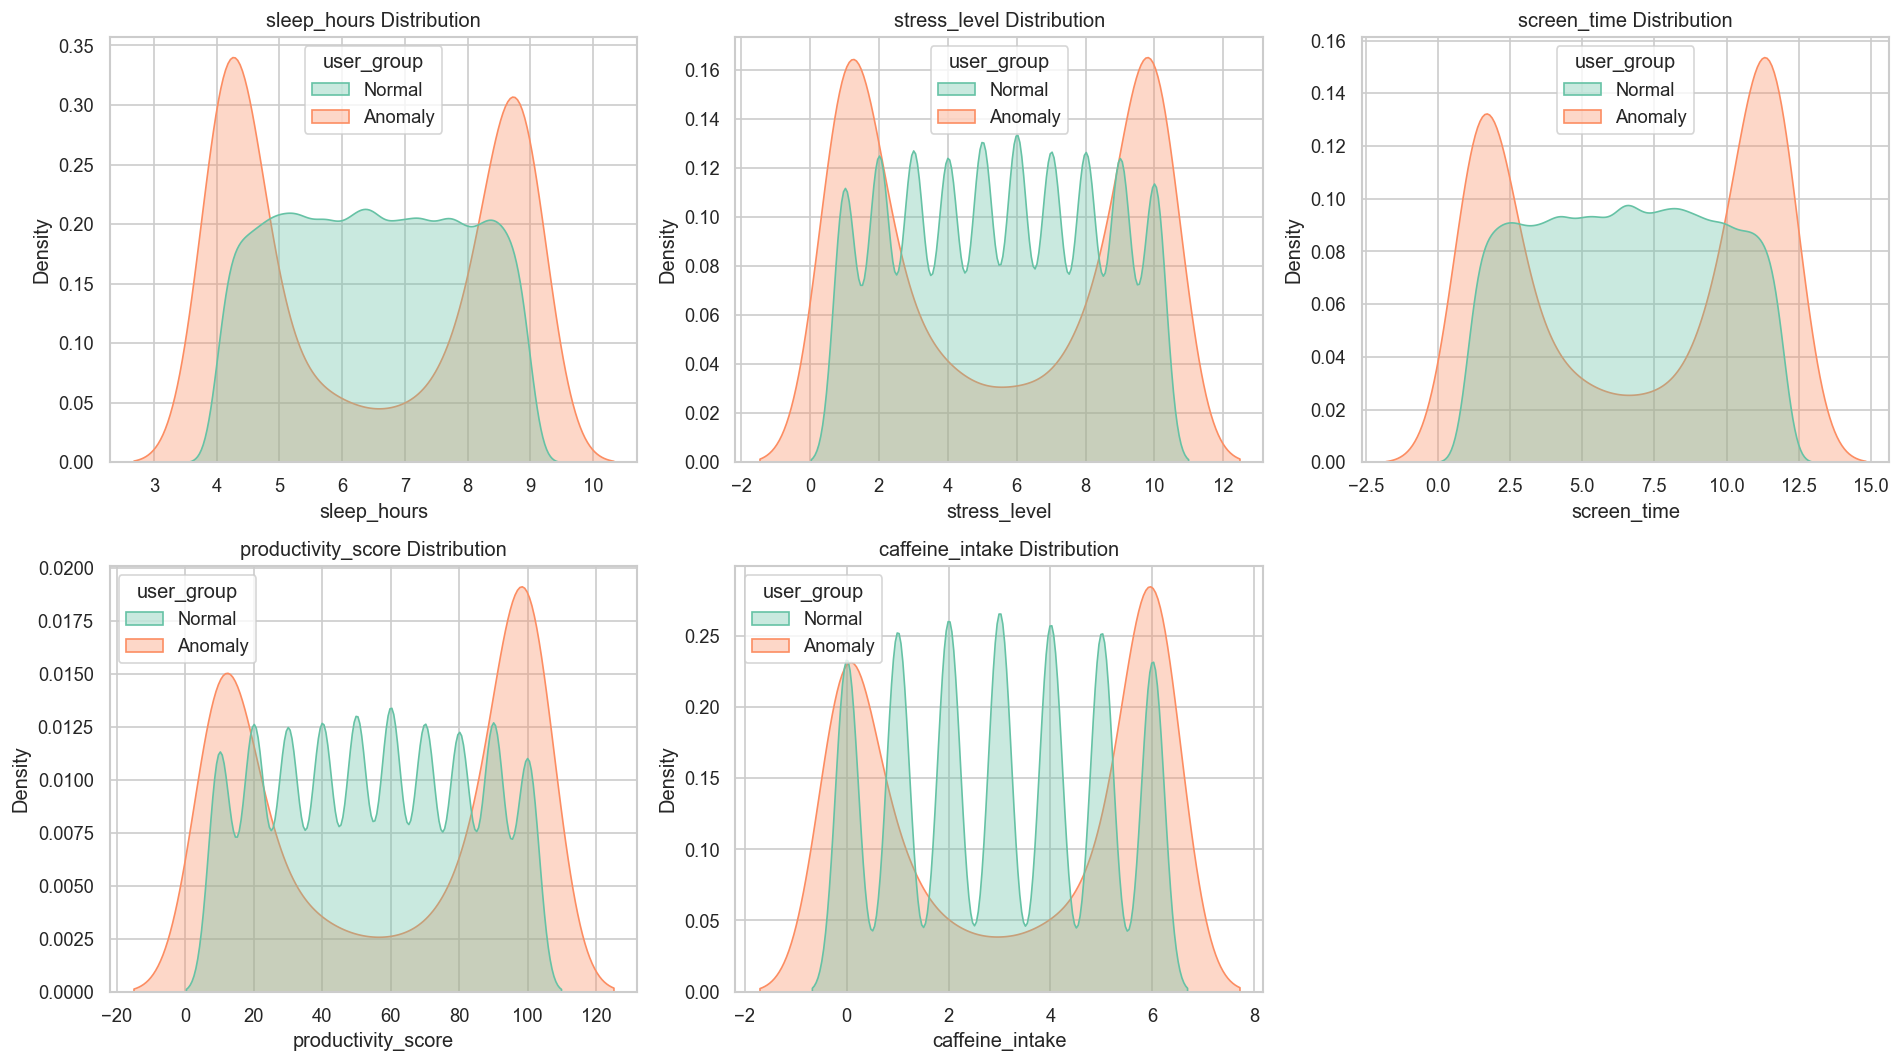

In [11]:
# 9.2 Feature Distribution Comparison
plot_df = df_clean.copy()
plot_df['user_group'] = plot_df['final_anomaly'].map({0: 'Normal', 1: 'Anomaly'})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(
        data=plot_df,
        x=feature,
        hue='user_group',
        fill=True,
        common_norm=False,
        alpha=0.35,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} Distribution')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

summary_stats = plot_df.groupby('user_group')[features].mean().T
summary_stats.columns = ['Anomaly Mean', 'Normal Mean'] if list(summary_stats.columns) == ['Anomaly', 'Normal'] else summary_stats.columns

print('Average feature values by group:')
display(plot_df.groupby('user_group')[features].mean())

## 10. Insight Extraction

This section automatically generates short text insights based on the anomaly detection results. The statements are designed to be simple, interpretable, and suitable for direct use in an academic report.

In [12]:
# Automatically generate short insights from the outputs.
normal_means = df_clean.loc[df_clean['final_anomaly'] == 0, features].mean()
anomaly_means = df_clean.loc[df_clean['final_anomaly'] == 1, features].mean()
mean_diff = (anomaly_means - normal_means).sort_values(key=lambda s: np.abs(s), ascending=False)

dominant_type = anomaly_type_counts.idxmax() if not anomaly_type_counts.empty else 'No anomaly type detected'
most_shifted_feature = mean_diff.index[0] if not mean_diff.empty else 'N/A'
second_shifted_feature = mean_diff.index[1] if len(mean_diff) > 1 else 'N/A'

print('Insight 1: Feature drivers')
print(f'- The largest average separation between anomalous and normal users appears in {most_shifted_feature} and {second_shifted_feature}.')

print('\nInsight 2: Dominant anomaly type')
print(f'- The most frequent anomaly category is {dominant_type}.')

print('\nInsight 3: Surprising pattern')
if 'Productivity Paradox' in anomaly_type_counts.index:
    print('- Some anomalous users maintain relatively high productivity despite limited sleep, indicating that productivity alone should not be interpreted as healthy behavior.')
else:
    print('- Most anomalies are explained better by broad behavioral irregularities than by the productivity paradox pattern.')

print('\nMean difference table (anomaly minus normal):')
display(mean_diff.to_frame(name='mean_difference'))

Insight 1: Feature drivers
- The largest average separation between anomalous and normal users appears in productivity_score and screen_time.

Insight 2: Dominant anomaly type
- The most frequent anomaly category is Behavioral Anomaly.

Insight 3: Surprising pattern
- Some anomalous users maintain relatively high productivity despite limited sleep, indicating that productivity alone should not be interpreted as healthy behavior.

Mean difference table (anomaly minus normal):


,mean_difference
productivity_score,4.17
screen_time,0.32
caffeine_intake,0.23
sleep_hours,-0.09
stress_level,-0.01


## 11. Optional Bonus: Feature Importance Approximation

The anomaly detection models above are unsupervised and do not all provide direct feature importance values. As a simple interpretation workaround, a Random Forest classifier is trained to predict the ensemble anomaly label. The resulting feature importances are used as an approximate indicator of which variables are most associated with anomalous behavior.

Approximate feature importance based on ensemble anomaly label:


<string>:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


,Feature,Importance
2,screen_time,0.28
0,sleep_hours,0.25
1,stress_level,0.19
3,productivity_score,0.15
4,caffeine_intake,0.14


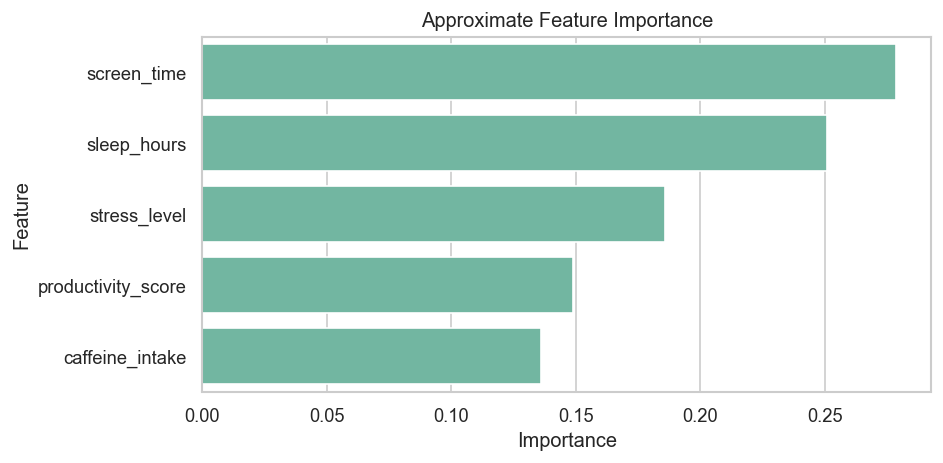

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(df_clean[features], df_clean['final_anomaly'])

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('Approximate feature importance based on ensemble anomaly label:')
display(importance_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Approximate Feature Importance')
plt.tight_layout()
plt.show()

## 12. Discussion

The ensemble model detected **2,180 anomalies out of 50,000 users**, equivalent to **4.36%** of the dataset. This rate is slightly lower than the anomaly counts from the individual models, where Isolation Forest and Local Outlier Factor each flagged 2,500 users and One-Class SVM flagged 2,502 users. This is a reasonable outcome because the ensemble rule requires agreement from at least two of the three models, which reduces false positives and produces a more conservative final anomaly set.

The overlap analysis also shows that model disagreement is non-trivial. A large majority of users (**45,376**) were classified as normal by all three methods, indicating a stable core of typical smartphone behavior. However, disagreement patterns such as `0-1-0` and `1-0-1` appear in noticeable numbers, which suggests that some users are only unusual under specific modeling assumptions. In practical terms, this supports the use of an ensemble approach because it balances local density-based anomalies, isolation-based anomalies, and boundary-based anomalies.

From the taxonomy classification, **Behavioral Anomaly** is the dominant category, accounting for **69.13%** of all final anomalies. This suggests that most abnormal users do not fit neatly into the strict rule-based categories of health risk or productivity paradox, but instead represent broader irregular combinations of behavior. **Health-Risk** anomalies contribute **18.85%**, showing that a meaningful subset of users combines low sleep with high stress. **Productivity Paradox** accounts for **12.02%**, confirming that some users remain highly productive despite reduced sleep, which may reflect unsustainable or hidden-risk behavioral patterns.

The feature comparison indicates that anomalous users differ most strongly from normal users in **productivity_score** and **screen_time**. On average, anomalous users show a productivity score that is about **4.17 points higher** and a screen time that is about **0.32 hours higher** than normal users. Smaller differences appear in caffeine intake and sleep hours, while stress level is nearly unchanged in the mean comparison. This implies that anomaly status in this dataset is not driven by a single extreme stress effect, but rather by more complex combinations of usage intensity, sleep behavior, and performance.

The approximate feature importance results provide an additional layer of interpretation. The most influential variables for predicting the final anomaly label are **screen_time (0.28)**, **sleep_hours (0.25)**, and **stress_level (0.19)**. This ranking is useful because it suggests that even though productivity score showed the largest mean difference, anomaly detection still depends heavily on the interaction between phone usage duration, sleep behavior, and psychological condition. In other words, anomalies are multivariate patterns rather than simple high-productivity outliers.

A particularly interesting finding is that anomalous users do not necessarily perform worse. In fact, the anomaly group has a higher average productivity score than the normal group. This is counterintuitive if anomaly is interpreted as failure or dysfunction. In this project, anomaly should instead be interpreted as **departure from common behavioral structure**, not automatically as poor performance. This distinction is important for academic discussion because it shows how anomaly detection can uncover risky or unusual user profiles even when traditional outcome variables appear favorable.

Overall, the results show that smartphone usage anomalies are best understood as **multidimensional behavioral deviations**. The combination of three unsupervised models, an ensemble decision rule, taxonomy-based labeling, and visualization creates a robust and interpretable workflow for anomaly detection. For future improvement, the study could include hyperparameter tuning, additional anomaly detection algorithms, or time-based smartphone usage variables to capture behavioral change over time.